# Ekstraksi dan Menampilkan Matriks Kernel

Notebook ini dibuat untuk memuat file `kernel_history.pkl` (atau `kernel_history_all.pkl`) dan menampilkan seluruh nilai matriks untuk setiap filter pada setiap channel di semua epoch.

In [1]:
import pickle
import numpy as np
import torch
import os

# Deteksi file history kernel
file_path = 'kernel_history.pkl'
if not os.path.exists(file_path):
    file_path = 'kernel_history_all.pkl'

print(f"Memuat data dari: {file_path} ...")
with open(file_path, 'rb') as f:
    kernel_history_all = pickle.load(f)

print("Berhasil memuat data!")
print(f"Jumlah layer yang terekam: {len(kernel_history_all)}")

Memuat data dari: kernel_history.pkl ...
Berhasil memuat data!
Jumlah layer yang terekam: 39


### 1. Visualisasi Heatmap Nilai Kontras Bobot (Filter 0, Channel 0)

Kode di bawah ini memvisualisasikan matriks filter 0 channel 0 dari Epoch 1 hingga 10 untuk setiap layer perwakilan menggunakan `seaborn.heatmap`.
- Untuk **Matriks 3x3**, ditampilkan dalam *grid* 2 baris × 5 kolom.
- Untuk **Matriks 1x1** (scalar), ditampilkan dalam bentuk **Pita Heatmap 1D (1x10)** mendatar yang sangat rapi untuk memperlihatkan tren evolusi bobot antar epoch.

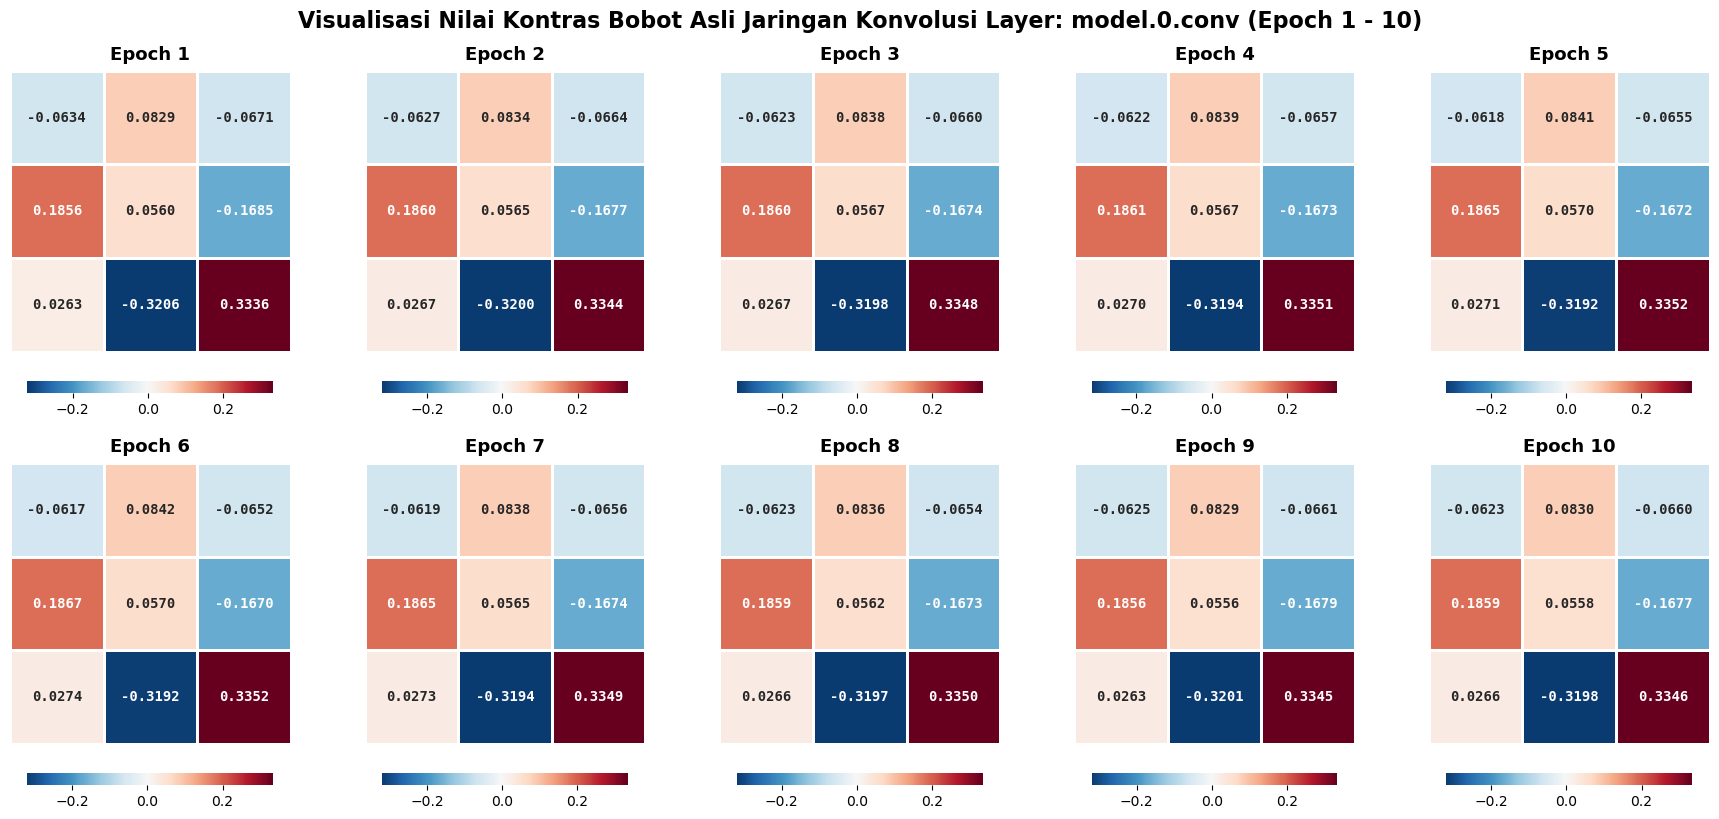

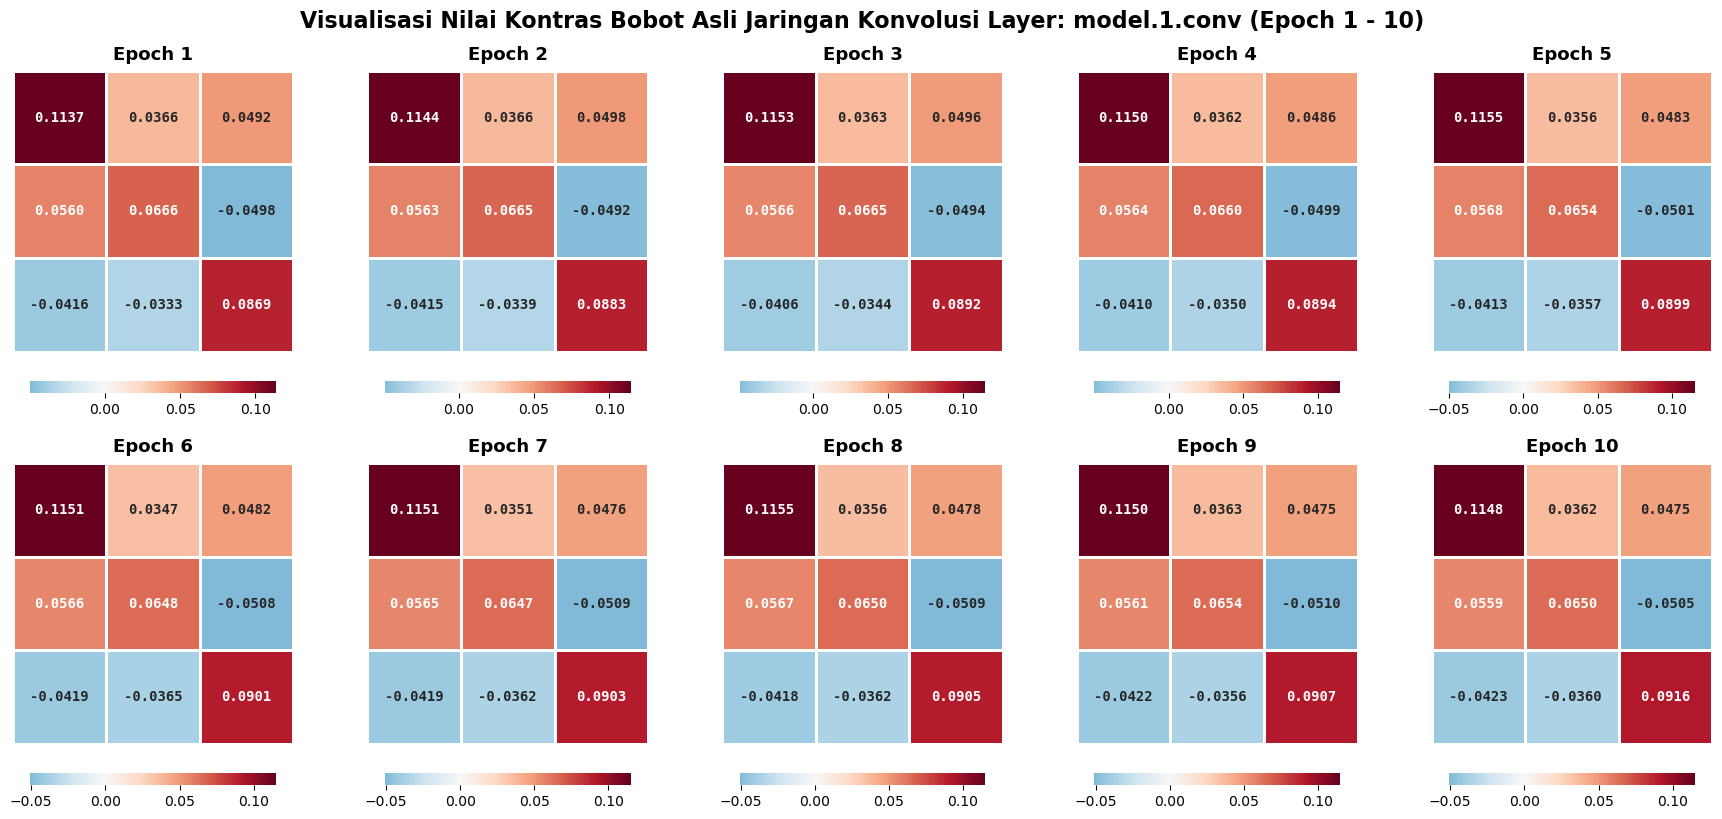

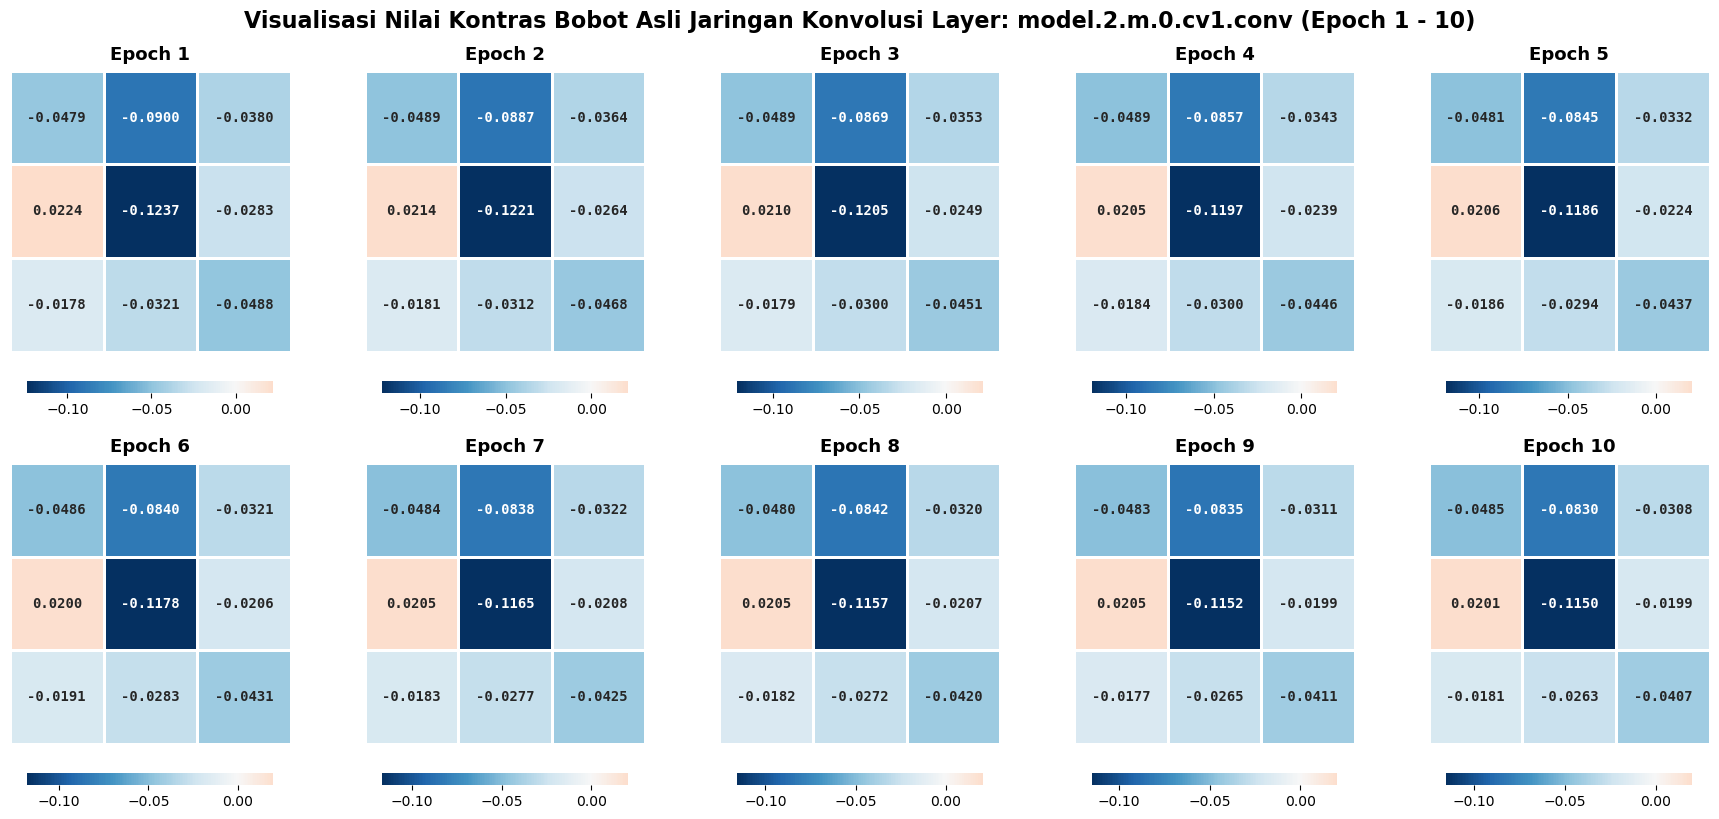

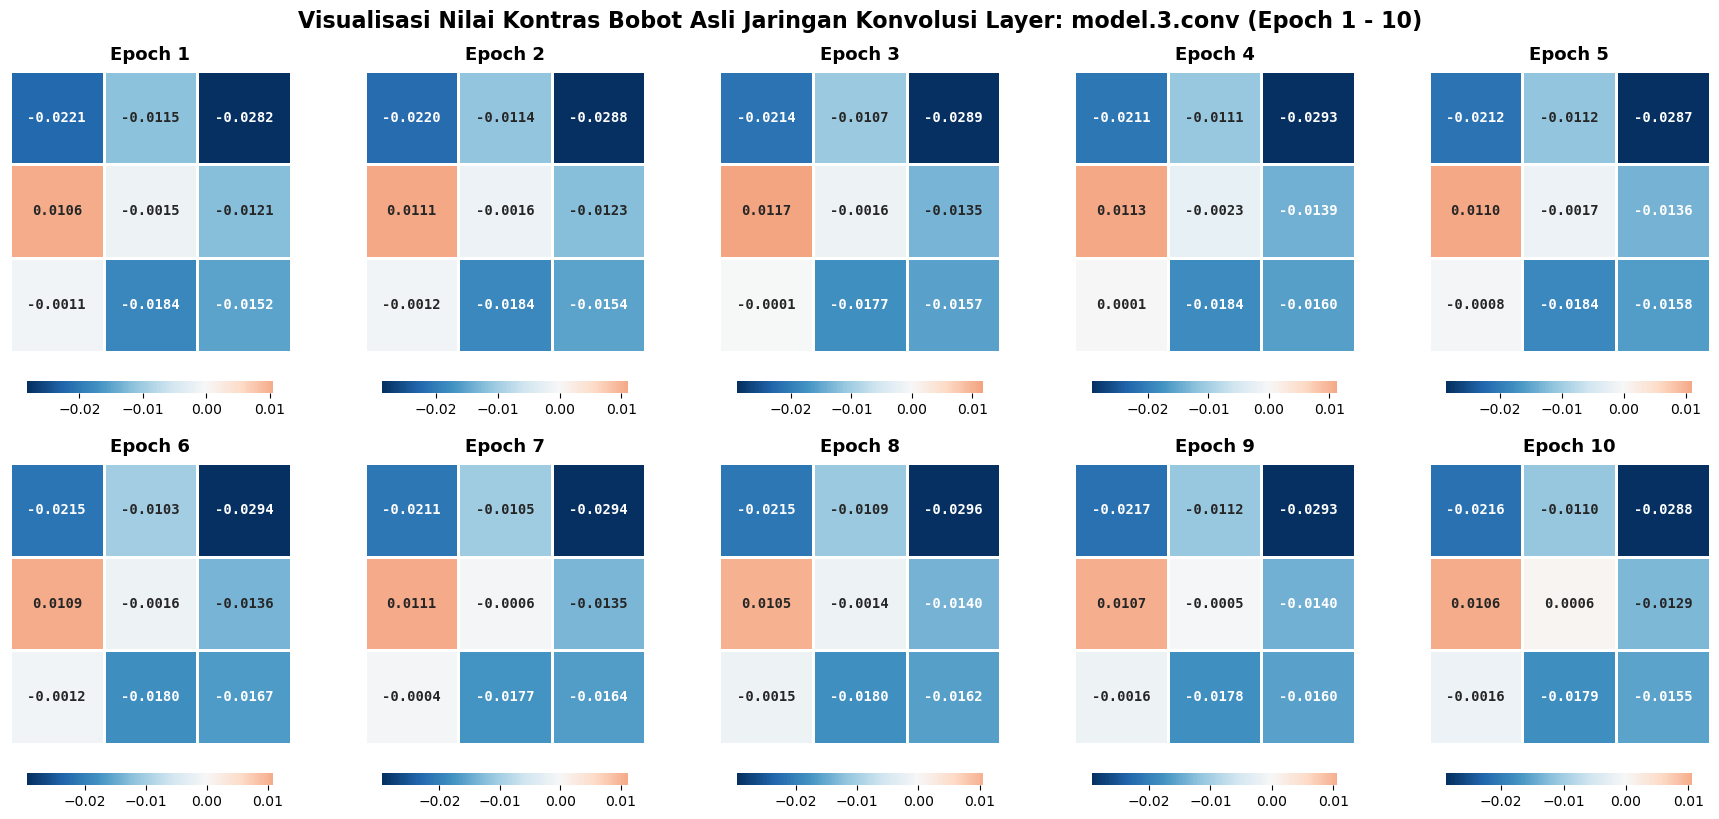

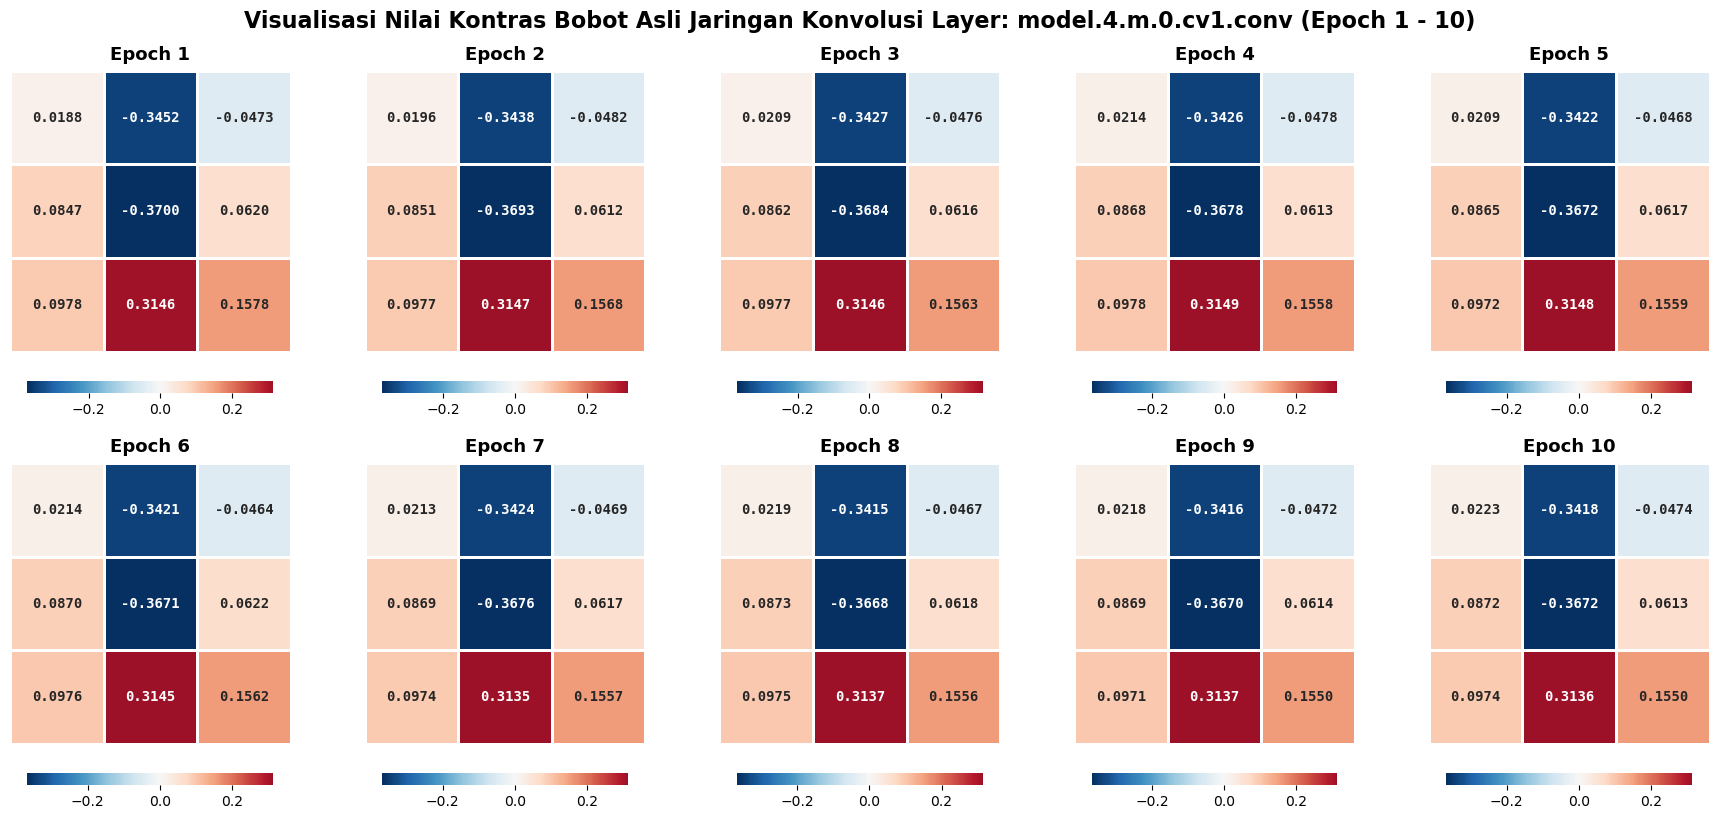

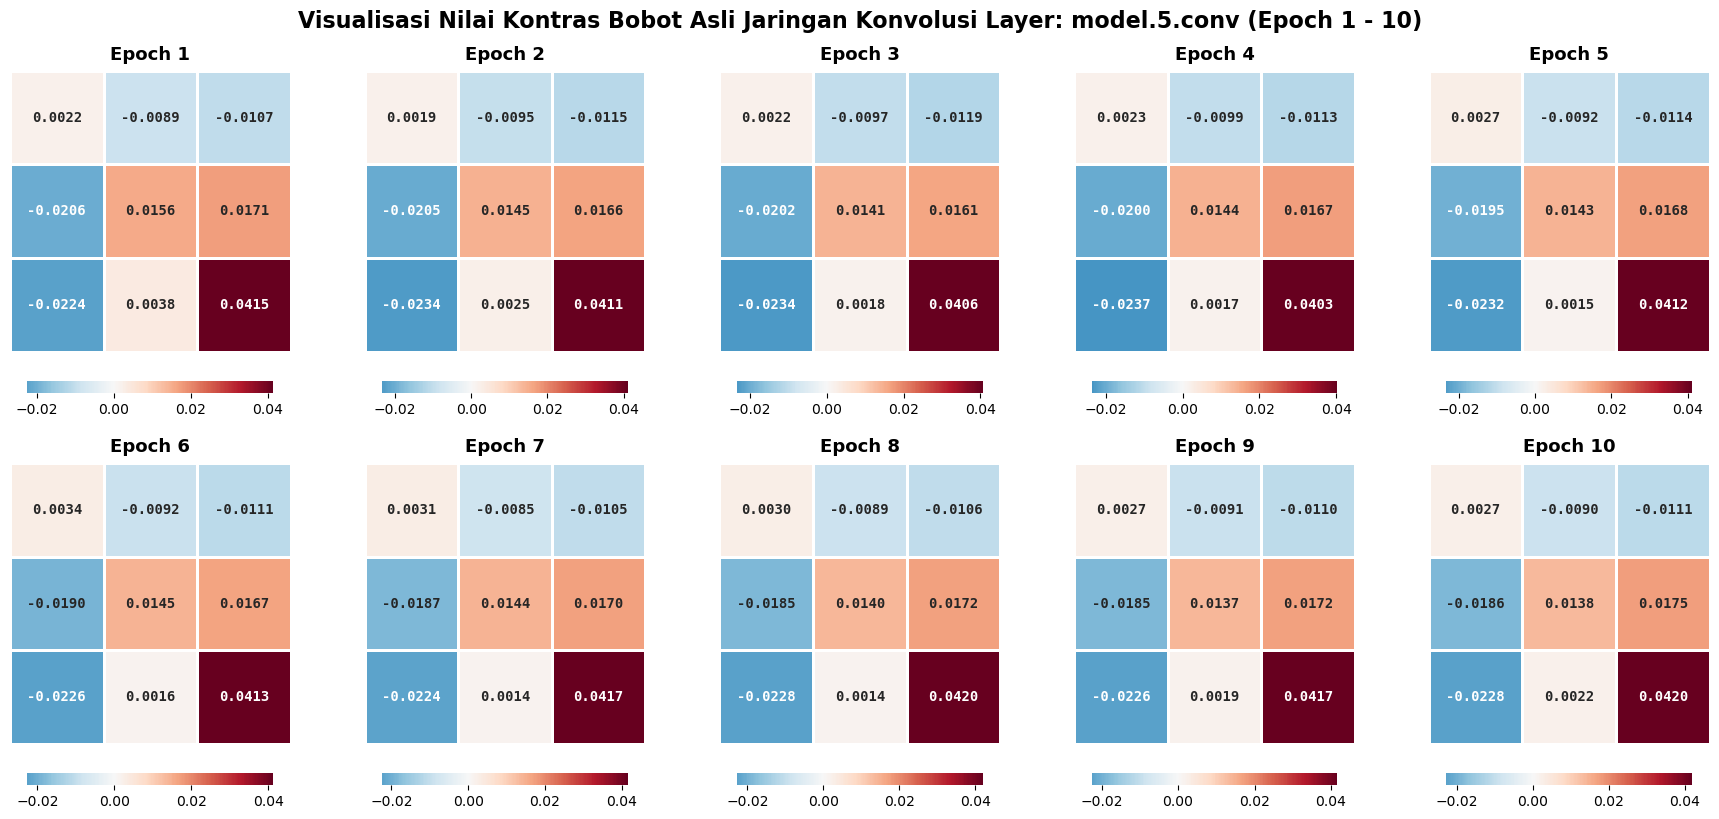

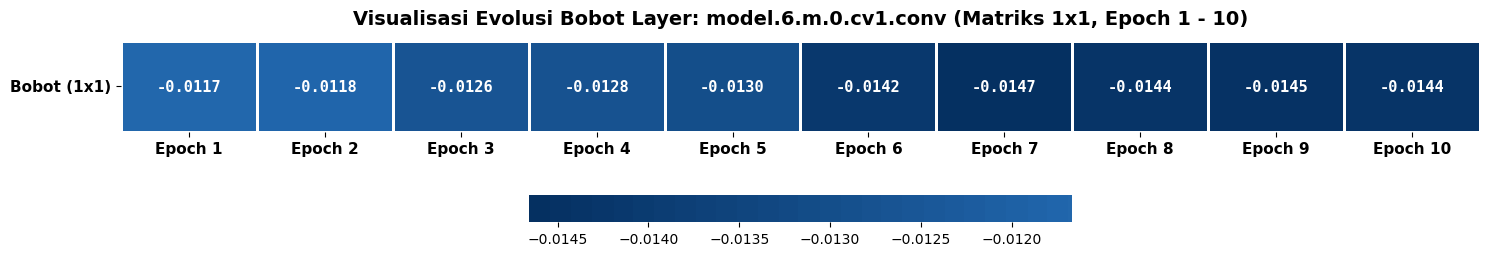

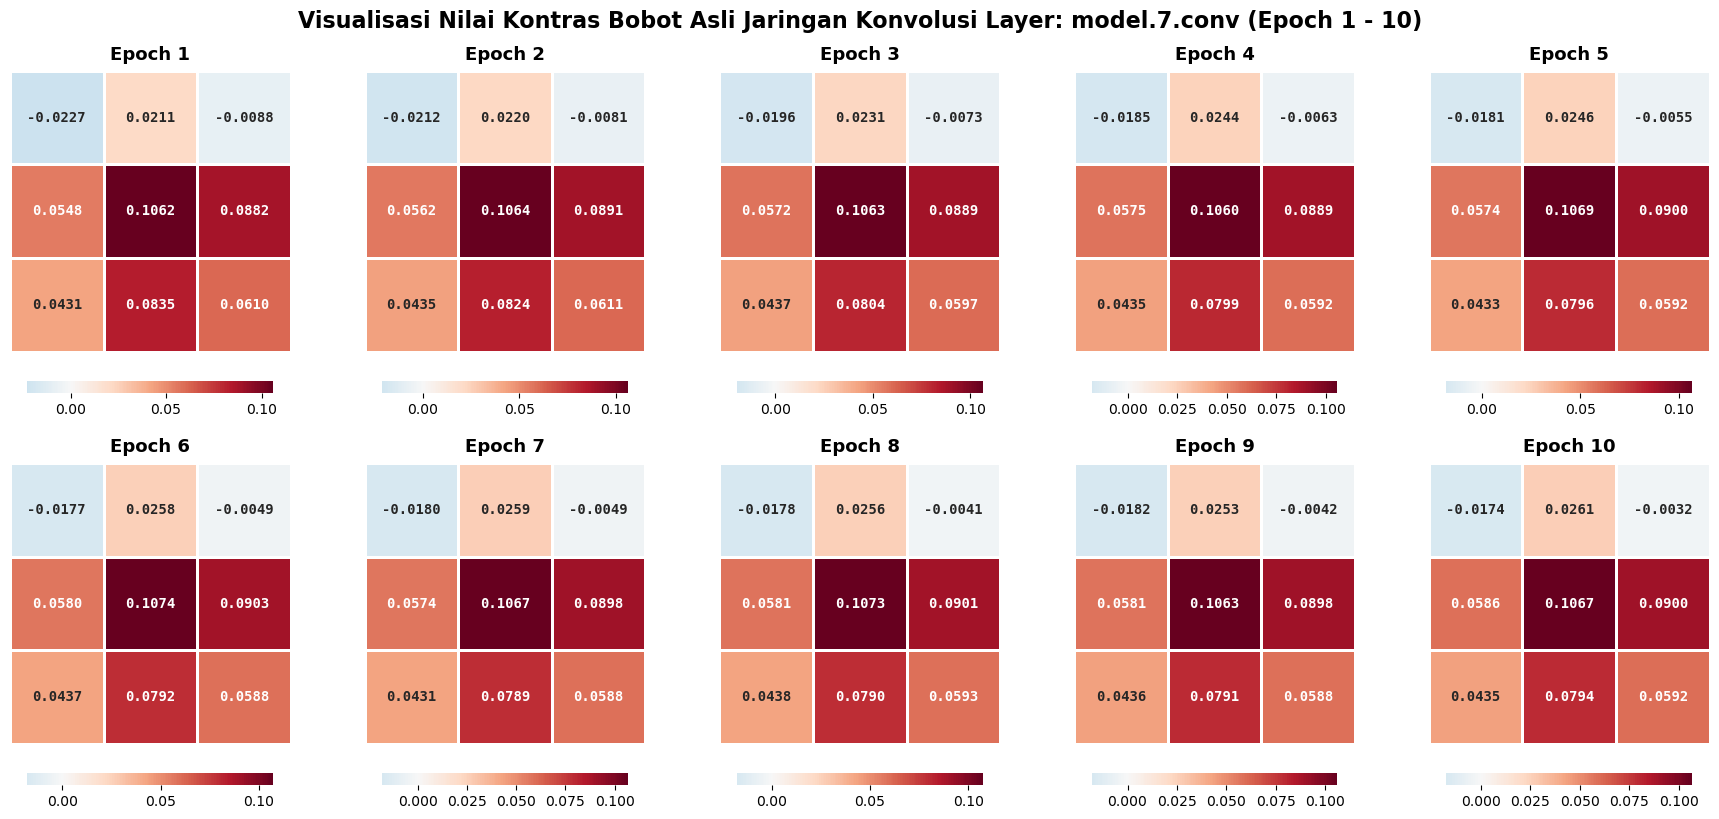

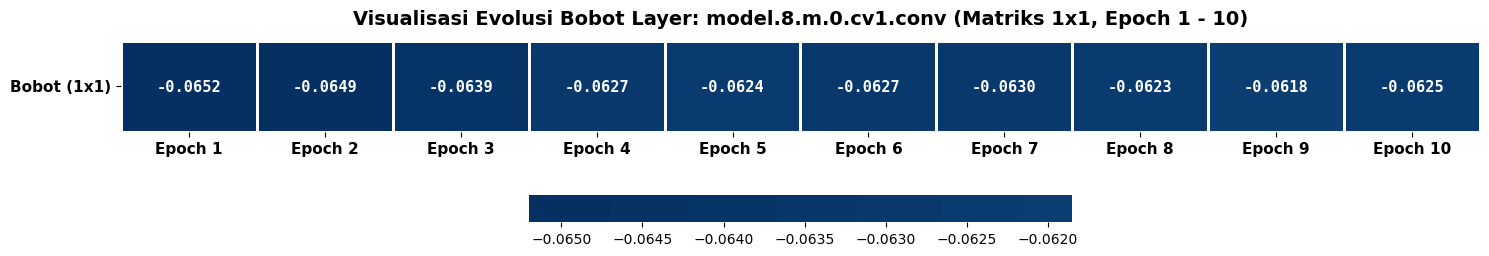

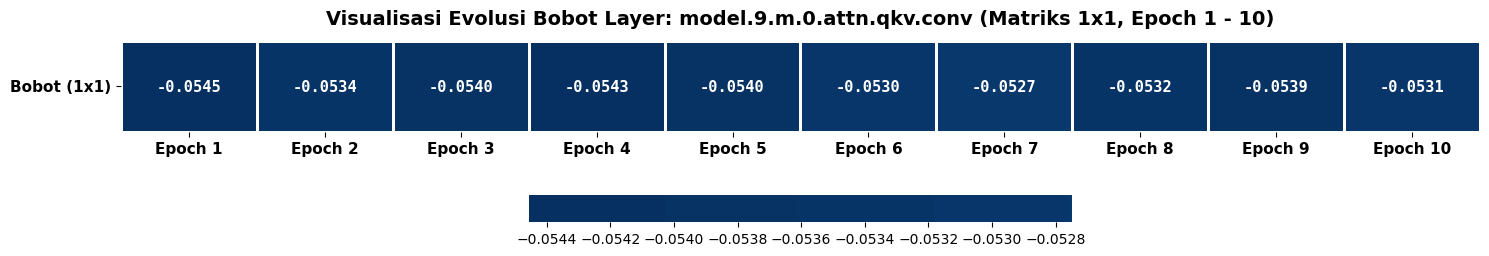

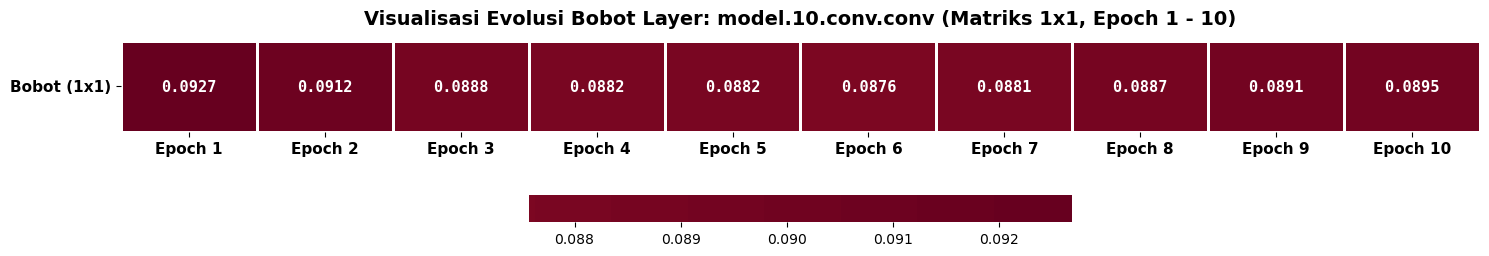

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

target_layers = [
    "model.0.conv",
    "model.1.conv",
    "model.2.m.0.cv1.conv",
    "model.3.conv",
    "model.4.m.0.cv1.conv",
    "model.5.conv",
    "model.6.m.0.cv1.conv",
    "model.7.conv",
    "model.8.m.0.cv1.conv",
    "model.9.m.0.attn.qkv.conv",
    "model.10.conv.conv"
]

for layer_name in target_layers:
    if layer_name not in kernel_history_all:
        print(f"Layer {layer_name} tidak ditemukan di history.")
        continue

    epochs_data = kernel_history_all[layer_name]
    num_epochs = min(len(epochs_data), 10)

    # Periksa ukuran matriks pada epoch pertama
    first_np = epochs_data[0].detach().cpu().numpy()
    if first_np.ndim >= 4:
        first_mat = first_np[0, 0]
    elif first_np.ndim == 3:
        first_mat = first_np[0]
    else:
        first_mat = first_np

    is_1x1 = (first_mat.size == 1)

    if is_1x1:
        # Tampilan khusus untuk Matriks 1x1: Pita Heatmap 1D (Epoch 1 - 10)
        values = []
        for i in range(num_epochs):
            ep_np = epochs_data[i].detach().cpu().numpy()
            if ep_np.ndim >= 4:
                val = ep_np[0, 0].flatten()[0]
            elif ep_np.ndim == 3:
                val = ep_np[0].flatten()[0]
            else:
                val = ep_np.flatten()[0]
            values.append(val)

        matrix_1d = np.array([values])

        fig, ax = plt.subplots(figsize=(15, 2.6))
        sns.heatmap(matrix_1d, annot=True, fmt=".4f", cmap="RdBu_r", center=0,
                    linewidths=2, linecolor='white', square=False, ax=ax,
                    cbar_kws={"orientation": "horizontal", "pad": 0.35, "shrink": 0.4},
                    annot_kws={"size": 11, "weight": "bold", "family": "monospace"})

        ax.set_xticklabels([f"Epoch {i+1}" for i in range(num_epochs)], fontsize=11, weight='bold')
        ax.set_yticklabels(["Bobot (1x1)"], fontsize=11, weight='bold', rotation=0)
        plt.title(f"Visualisasi Evolusi Bobot Layer: {layer_name} (Matriks 1x1, Epoch 1 - 10)", fontsize=14, weight='bold', pad=12)
        plt.tight_layout()
        plt.show()

    else:
        # Tampilan standar Grid 2x5 untuk Matriks 3x3
        fig, axes = plt.subplots(2, 5, figsize=(18, 8.5))
        axes = axes.flatten()

        for i in range(num_epochs):
            epoch = i + 1
            epoch_np = epochs_data[i].detach().cpu().numpy()

            if epoch_np.ndim >= 4:
                matrix = epoch_np[0, 0]
            elif epoch_np.ndim == 3:
                matrix = epoch_np[0]
            else:
                matrix = epoch_np

            if matrix.ndim == 1:
                matrix = np.expand_dims(matrix, axis=0)

            sns.heatmap(matrix, annot=True, fmt=".4f", cmap="RdBu_r", center=0,
                        linewidths=2, linecolor='white', square=True, ax=axes[i],
                        cbar_kws={"shrink": 0.7, "orientation": "horizontal", "pad": 0.08},
                        annot_kws={"size": 10, "weight": "bold", "family": "monospace"})

            axes[i].set_title(f"Epoch {epoch}", fontsize=13, weight='bold', pad=8)
            axes[i].set_xticks([])
            axes[i].set_yticks([])

        for j in range(num_epochs, 10):
            axes[j].axis('off')

        plt.suptitle(f"Visualisasi Nilai Kontras Bobot Asli Jaringan Konvolusi Layer: {layer_name} (Epoch 1 - 10)", fontsize=16, weight='bold', y=0.98)
        plt.tight_layout()
        plt.show()

### 2. Menampilkan Nilai Matriks Seluruh Layer pada Setiap Blok (Tabel Kompak)

Untuk menghindari keterputusan tampilan (*there are more than 500 outputs*) pada browser/notebook, nilai dari Epoch 1 hingga 10 untuk setiap elemen matriks digabungkan ke dalam **satu tabel kompak per layer**.
Tiap baris merepresentasikan posisi elemen koordinat matriks (misal `[0, 0]`), dan tiap kolom merepresentasikan Epoch.

In [3]:
import sys
import numpy as np
import torch
import pandas as pd
from IPython.display import display, HTML

np.set_printoptions(suppress=True)
torch.set_printoptions(profile="full", sci_mode=False)

def print_all_blocks_kernels_table_compact(history_dict, target_filter_idx=0, target_channel_idx=0):
    """
    Menampilkan nilai matriks (kernel) dalam bentuk Tabel Pandas yang kompak.
    Mencetak nilai matriks untuk SEMUA layer pada setiap blok (Filter 0, Channel 0).
    Menggabungkan Epoch 1-10 menjadi kolom-kolom dalam 1 tabel per layer agar tidak terkena limit output.
    """
    blocks = {}
    for layer_name in history_dict.keys():
        parts = layer_name.split('.')
        if len(parts) >= 2 and parts[1].isdigit():
            block_id = int(parts[1])
            block_name = f"model.{block_id}"
        else:
            block_id = 999
            block_name = "other"
        blocks.setdefault((block_id, block_name), []).append(layer_name)

    sorted_blocks = sorted(blocks.items(), key=lambda x: x[0][0])

    for (block_id, block_name), layers_in_block in sorted_blocks:
        total_layers = len(layers_in_block)
        display(HTML(f"<h2 style='background-color:#2c3e50; color:white; padding:12px; margin-top:30px; border-radius:5px;'>BLOK: {block_name.upper()} ({total_layers} Layer)</h2>"))

        for layer_idx, layer_name in enumerate(layers_in_block, start=1):
            epochs_data = history_dict[layer_name]

            # Header Layer dengan informasi lengkap
            display(HTML(f"""
            <div style='background-color:#4CAF50; color:white; padding:10px; border-radius:4px; margin-top:15px;'>
                <h3 style='margin:0; padding:0;'>LAYER: {layer_name}</h3>
                <p style='margin:5px 0 0 0; font-size:14px;'>
                    <b>Asal Blok:</b> {block_name} &nbsp;|&nbsp;
                    <b>Urutan Layer:</b> Ke-{layer_idx} dari {total_layers} layer pada blok ini &nbsp;|&nbsp;
                    <b>Filter/Channel:</b> {target_filter_idx}/{target_channel_idx}
                </p>
            </div>
            """))

            table_data = {}
            row_labels = None

            for epoch_idx, epoch_tensor in enumerate(epochs_data):
                epoch_np = epoch_tensor.detach().cpu().numpy()
                ndim = epoch_np.ndim
                num_filters = epoch_np.shape[0]
                num_channels = epoch_np.shape[1] if ndim > 1 else 1

                if target_filter_idx >= num_filters:
                    continue

                if ndim >= 2 and target_channel_idx < num_channels:
                    if ndim >= 3:
                        matrix = epoch_np[target_filter_idx, target_channel_idx]
                    else:
                        matrix = epoch_np[target_filter_idx]
                else:
                    matrix = epoch_np[target_filter_idx]

                if row_labels is None:
                    if matrix.ndim == 2:
                        h, w = matrix.shape
                        row_labels = [f"Elemen [{r}, {c}]" for r in range(h) for c in range(w)]
                    elif matrix.ndim == 1:
                        row_labels = [f"Elemen [{i}]" for i in range(len(matrix))]
                    else:
                        row_labels = ["Elemen [0]"]

                table_data[f"Epoch {epoch_idx + 1}"] = matrix.flatten()

            if table_data:
                df = pd.DataFrame(table_data, index=row_labels)
                df.index.name = "Posisi Matriks"
                styled_df = df.style.format("{:.4f}").background_gradient(cmap='coolwarm', axis=None)
                display(styled_df)
            else:
                print(f"Data filter {target_filter_idx} / channel {target_channel_idx} tidak tersedia.")

            display(HTML("<hr style='border:1px dashed #ccc;'>"))

print("Mencetak nilai matriks seluruh layer pada setiap blok secara kompak...")
print_all_blocks_kernels_table_compact(kernel_history_all, target_filter_idx=0, target_channel_idx=0)

Mencetak nilai matriks seluruh layer pada setiap blok secara kompak...


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",-0.0634,-0.0627,-0.0623,-0.0622,-0.0618,-0.0617,-0.0619,-0.0623,-0.0625,-0.0623
"Elemen [0, 1]",0.0829,0.0834,0.0838,0.0839,0.0841,0.0842,0.0838,0.0836,0.0829,0.0830
"Elemen [0, 2]",-0.0671,-0.0664,-0.0660,-0.0657,-0.0655,-0.0652,-0.0656,-0.0654,-0.0661,-0.0660
"Elemen [1, 0]",0.1856,0.1860,0.1860,0.1861,0.1865,0.1867,0.1865,0.1859,0.1856,0.1859
"Elemen [1, 1]",0.0560,0.0565,0.0567,0.0567,0.0570,0.0570,0.0565,0.0562,0.0556,0.0558
"Elemen [1, 2]",-0.1685,-0.1677,-0.1674,-0.1673,-0.1672,-0.1670,-0.1674,-0.1673,-0.1679,-0.1677
"Elemen [2, 0]",0.0263,0.0267,0.0267,0.0270,0.0271,0.0274,0.0273,0.0266,0.0263,0.0266
"Elemen [2, 1]",-0.3206,-0.3200,-0.3198,-0.3194,-0.3192,-0.3192,-0.3194,-0.3197,-0.3201,-0.3198
"Elemen [2, 2]",0.3336,0.3344,0.3348,0.3351,0.3352,0.3352,0.3349,0.3350,0.3345,0.3346


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",0.1137,0.1144,0.1153,0.1150,0.1155,0.1151,0.1151,0.1155,0.1150,0.1148
"Elemen [0, 1]",0.0366,0.0366,0.0363,0.0362,0.0356,0.0347,0.0351,0.0356,0.0363,0.0362
"Elemen [0, 2]",0.0492,0.0498,0.0496,0.0486,0.0483,0.0482,0.0476,0.0478,0.0475,0.0475
"Elemen [1, 0]",0.0560,0.0563,0.0566,0.0564,0.0568,0.0566,0.0565,0.0567,0.0561,0.0559
"Elemen [1, 1]",0.0666,0.0665,0.0665,0.0660,0.0654,0.0648,0.0647,0.0650,0.0654,0.0650
"Elemen [1, 2]",-0.0498,-0.0492,-0.0494,-0.0499,-0.0501,-0.0508,-0.0509,-0.0509,-0.0510,-0.0505
"Elemen [2, 0]",-0.0416,-0.0415,-0.0406,-0.0410,-0.0413,-0.0419,-0.0419,-0.0418,-0.0422,-0.0423
"Elemen [2, 1]",-0.0333,-0.0339,-0.0344,-0.0350,-0.0357,-0.0365,-0.0362,-0.0362,-0.0356,-0.0360
"Elemen [2, 2]",0.0869,0.0883,0.0892,0.0894,0.0899,0.0901,0.0903,0.0905,0.0907,0.0916


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",0.0821,0.0824,0.0826,0.0824,0.0818,0.0818,0.0814,0.0810,0.0816,0.0817


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",0.0302,0.0310,0.0316,0.0317,0.0315,0.0313,0.0313,0.0304,0.0302,0.0301


...

,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",-0.0113,-0.0105,-0.0105,-0.0111,-0.0112,-0.0112,-0.0117,-0.0112,-0.0111,-0.0113


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",-0.0786,-0.0802,-0.0821,-0.0831,-0.0832,-0.0827,-0.0835,-0.0836,-0.0828,-0.0824
"Elemen [0, 1]",-0.1762,-0.1764,-0.1771,-0.1776,-0.1776,-0.1778,-0.1782,-0.1775,-0.1769,-0.1769
"Elemen [0, 2]",-0.0712,-0.0698,-0.0690,-0.0705,-0.0713,-0.0730,-0.0737,-0.0738,-0.0743,-0.0750
"Elemen [1, 0]",-0.1320,-0.1344,-0.1371,-0.1380,-0.1384,-0.1381,-0.1383,-0.1389,-0.1384,-0.1385
"Elemen [1, 1]",0.0813,0.0795,0.0773,0.0768,0.0767,0.0767,0.0770,0.0770,0.0771,0.0774
"Elemen [1, 2]",-0.1281,-0.1259,-0.1253,-0.1257,-0.1264,-0.1274,-0.1275,-0.1276,-0.1284,-0.1288
"Elemen [2, 0]",-0.0654,-0.0682,-0.0688,-0.0681,-0.0676,-0.0667,-0.0656,-0.0655,-0.0654,-0.0651
"Elemen [2, 1]",-0.1294,-0.1299,-0.1289,-0.1266,-0.1254,-0.1244,-0.1233,-0.1232,-0.1234,-0.1227
"Elemen [2, 2]",-0.0719,-0.0697,-0.0671,-0.0659,-0.0657,-0.0655,-0.0650,-0.0651,-0.0660,-0.0660


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",-0.0243,-0.0260,-0.0259,-0.0254,-0.0251,-0.0251,-0.0252,-0.0252,-0.0250,-0.0249


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",-0.1636,-0.1617,-0.1608,-0.1597,-0.1602,-0.1603,-0.1601,-0.1596,-0.1603,-0.1605


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10
Posisi Matriks,,,,,,,,,,
"Elemen [0, 0]",0.0927,0.0912,0.0888,0.0882,0.0882,0.0876,0.0881,0.0887,0.0891,0.0895


### 3. Menyimpan Seluruh Nilai ke File Teks (`kernels/all_layers.txt`)

Sel di bawah ini akan menyimpan rekapitulasi lengkap nilai bobot untuk **seluruh 39 layer** ke dalam file tunggal `kernels/all_layers.txt`, serta menyimpan file terpisah per layer di dalam folder `kernels/`.

In [4]:
import os
import numpy as np
from multiprocessing import Pool
from io import StringIO

def export_all_layers_single_file(history_dict, filepath="kernels/all_layers.txt"):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

    with open(filepath, "w", encoding="utf-8") as f:
        f.write("=" * 70 + "\n")
        f.write("REKAPITULASI NILAI BOBOT MATRIKS SELURUH LAYER (EPOCH 1 - 10)\n")
        f.write("=" * 70 + "\n\n")

        # Urutkan layer berdasarkan blok
        blocks = {}
        for layer_name in history_dict.keys():
            parts = layer_name.split('.')
            block_id = int(parts[1]) if len(parts) >= 2 and parts[1].isdigit() else 999
            blocks.setdefault(block_id, []).append(layer_name)

        for block_id in sorted(blocks.keys()):
            block_name = f"model.{block_id}" if block_id != 999 else "other"
            f.write("*" * 60 + "\n")
            f.write(f"BLOK: {block_name.upper()}\n")
            f.write("*" * 60 + "\n\n")

            for layer_idx, layer_name in enumerate(blocks[block_id], start=1):
                epochs_data = history_dict[layer_name]
                total_layers = len(blocks[block_id])

                f.write("-" * 50 + "\n")
                f.write(f"Layer Ke-{layer_idx}/{total_layers}: {layer_name}\n")
                f.write("-" * 50 + "\n")

                for epoch_idx, epoch_tensor in enumerate(epochs_data):
                    epoch_np = epoch_tensor.detach().cpu().numpy()
                    ndim = epoch_np.ndim

                    if ndim >= 4:
                        matrix = epoch_np[0, 0]
                    elif ndim == 3:
                        matrix = epoch_np[0]
                    else:
                        matrix = epoch_np

                    f.write(f"\n  [Epoch {epoch_idx + 1}] (Filter 0, Channel 0):\n")
                    matrix_str = np.array2string(matrix, separator=", ", prefix="    ")
                    f.write(f"    {matrix_str}\n")
                f.write("\n" + "=" * 50 + "\n\n")

    print(f"✓ Berhasil menyimpan rekapitulasi seluruh layer ke: {filepath}")

def _write_layer_worker(args):
    layer_name, epochs_list, export_dir = args
    safe_name = layer_name.replace(".", "_")
    file_path = os.path.join(export_dir, f"{safe_name}.txt")

    buf = StringIO()
    buf.write("=" * 50 + "\n")
    buf.write(f"LAYER: {layer_name}\n")
    buf.write("=" * 50 + "\n")

    for epoch_idx, epoch_np in enumerate(epochs_list):
        buf.write(f"\n--- EPOCH {epoch_idx + 1} ---\n")
        ndim = epoch_np.ndim
        if ndim >= 4:
            matrix = epoch_np[0, 0]
        elif ndim == 3:
            matrix = epoch_np[0]
        else:
            matrix = epoch_np
        matrix_str = np.array2string(matrix, separator=", ", prefix="  ")
        buf.write(f"  {matrix_str}\n")

    with open(file_path, "w", encoding="utf-8", buffering=1024 * 1024) as f:
        f.write(buf.getvalue())
    return layer_name

def export_kernels_to_txt_fast(history_dict, export_dir="kernels"):
    os.makedirs(export_dir, exist_ok=True)
    export_all_layers_single_file(history_dict, os.path.join(export_dir, "all_layers.txt"))

    target_layers = list(history_dict.keys())
    tasks = []
    for layer_name in target_layers:
        epochs_data = history_dict[layer_name]
        epochs_np = [t.detach().cpu().numpy() for t in epochs_data]
        tasks.append((layer_name, epochs_np, export_dir))

    print(f"Mengekspor {len(tasks)} file individual layer ke folder {export_dir}...")
    with Pool(processes=min(len(tasks), os.cpu_count() or 1)) as pool:
        for layer_name in pool.imap_unordered(_write_layer_worker, tasks):
            pass
    print(f"✓ Selesai semua ekspor!")

export_kernels_to_txt_fast(kernel_history_all)


✓ Berhasil menyimpan rekapitulasi seluruh layer ke: kernels/all_layers.txt
Mengekspor 39 file individual layer ke folder kernels...
✓ Selesai semua ekspor!
